#  Part 1: Understanding the Problem with Messy Data

### **1.1** -  Create a Messy Dataset

In [8]:
import pandas as pd
import numpy as np

np.random.seed(42)
n=200

data = {
    'age': np.random.randint(18,80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol' : np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6,0.4])
}

df = pd.DataFrame(data)

missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], 'age'] = np.nan
df.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df.loc[missing_idx[15:], 'cholesterol'] = np.nan

print ( f'Dataset shape : {df. shape }')
print ( f'\nFirst 5 rows :')
print ( df . head () )
print ( f'\nMissing values per column :')
print(df.isnull().sum())

Dataset shape : (200, 8)

First 5 rows :
    age  blood_pressure  cholesterol   bmi  gender    city smoker  \
0  56.0           171.7        295.2  34.4    Male  Riyadh     No   
1  69.0           112.4        345.2  21.9  Female  Dammam     No   
2  46.0           126.9        253.3  39.9  Female  Jeddah     No   
3  32.0           158.0        214.6  37.7  Female  Riyadh     No   
4  60.0           110.6        309.0  40.8    Male  Makkah    Yes   

   heart_disease  
0              1  
1              0  
2              0  
3              1  
4              1  

Missing values per column :
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64


### 1.2 - Identify the Issues

In [9]:
print('=== Data Types ===')
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Numeric Ranges ===")
print(df.describe().round(2))

print('\n=== Categorical Columns ===')
for col in ['gender', 'city', 'smoker']:
  print(f"{col}: {df[col].unique()}")

=== Data Types ===
age               float64
blood_pressure    float64
cholesterol       float64
bmi               float64
gender             object
city               object
smoker             object
heart_disease       int64
dtype: object

=== Missing Values ===
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64

=== Numeric Ranges ===
          age  blood_pressure  cholesterol     bmi  heart_disease
count  190.00          195.00       195.00  200.00         200.00
mean    49.31          136.03       252.28   29.33           0.44
std     18.71           26.48        60.97    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.00          112.20       205.75   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     65.00          159.75       301.95   34.67           1.00
ma

In [10]:
print(df.info())

print("\nPercentage of missing values in each column:")
print((df.isnull().sum()/len(df))*100)
# The column for 'age' has the most missing values

df['city'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             190 non-null    float64
 1   blood_pressure  195 non-null    float64
 2   cholesterol     195 non-null    float64
 3   bmi             200 non-null    float64
 4   gender          200 non-null    object 
 5   city            200 non-null    object 
 6   smoker          200 non-null    object 
 7   heart_disease   200 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 12.6+ KB
None

Percentage of missing values in each column:
age               5.0
blood_pressure    2.5
cholesterol       2.5
bmi               0.0
gender            0.0
city              0.0
smoker            0.0
heart_disease     0.0
dtype: float64


,count
city,
Dammam,59
Jeddah,52
Riyadh,47
Makkah,42


# Part 2: Handling Missing Values

### 2.1 - Inpute Numeric Columns

In [11]:
from sklearn.impute import SimpleImputer

numeric_cols =  ["age", "blood_pressure", "cholesterol"]

imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print('Missing values after imputation:')
print(df.isnull().sum())

print(imputer.statistics_)

Missing values after imputation:
age               0
blood_pressure    0
cholesterol       0
bmi               0
gender            0
city              0
smoker            0
heart_disease     0
dtype: int64
[ 50.  138.2 255.5]


### 2.2 Verify the Fix

In [12]:
print(f"Total missing values in entire dataset: {df.isnull().sum().sum()}")
print(f"\nDataset shape: {df.shape}")
print(df.describe().round(2))

Total missing values in entire dataset: 0

Dataset shape: (200, 8)
          age  blood_pressure  cholesterol     bmi  heart_disease
count  200.00          200.00       200.00  200.00         200.00
mean    49.34          136.08       252.36   29.33           0.44
std     18.23           26.15        60.20    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.75          112.62       206.15   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     64.00          158.70       301.08   34.67           1.00
max     79.00          179.10       348.60   42.00           1.00


**1-** Missing values are filled with the following values using the median: [ 49.345,  136.0825, 252.361 ]

**2-** Missing values are filled with the following values using the mean: [ 49.345,  136.0825, 252.361 ]


**Note: imputer.statistics_ show the numbers of mean and median**

**3-** We lose 20 rows with df.dropna(), which is unacceptable for a sample size of 200

# Part 3: Encoding Categorical Variables

### 3.1 - Label Encoding for Binary Variables

In [13]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'])

le_smoker = LabelEncoder()
df['smoker_encoded'] = le_smoker.fit_transform(df['smoker'])

print('Original vs Encoded:')
print(df[['gender', 'gender_encoded', 'smoker', 'smoker_encoded']].head(8))

Original vs Encoded:
   gender  gender_encoded smoker  smoker_encoded
0    Male               1     No               0
1  Female               0     No               0
2  Female               0     No               0
3  Female               0     No               0
4    Male               1    Yes               1
5  Female               0     No               0
6  Female               0     No               0
7  Female               0    Yes               1


### 3.2 - One-Hot Encoding for Multi-Category Variables

In [14]:
city_dummies = pd.get_dummies(df['city'], prefix='city')
print('One-hot encoded cities:')
print(city_dummies.head())

df = pd.concat([df, city_dummies], axis=1)
df = df.drop(columns=['gender','city', 'smoker'])

print(f"\nNew shape: {df.shape}")
print (f'New columns : {list(df.columns)}')


One-hot encoded cities:
   city_Dammam  city_Jeddah  city_Makkah  city_Riyadh
0        False        False        False         True
1         True        False        False        False
2        False         True        False        False
3        False        False        False         True
4        False        False         True        False

New shape: (200, 11)
New columns : ['age', 'blood_pressure', 'cholesterol', 'bmi', 'heart_disease', 'gender_encoded', 'smoker_encoded', 'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']


In [15]:
print(df.head(10))
print(df.shape)

    age  blood_pressure  cholesterol   bmi  heart_disease  gender_encoded  \
0  56.0           171.7        295.2  34.4              1               1   
1  69.0           112.4        345.2  21.9              0               0   
2  46.0           126.9        253.3  39.9              0               0   
3  32.0           158.0        214.6  37.7              1               0   
4  60.0           110.6        309.0  40.8              1               1   
5  25.0            96.9        204.2  35.4              0               0   
6  78.0           116.1        237.8  32.7              1               0   
7  38.0           104.5        165.7  28.0              0               0   
8  56.0           173.7        155.1  40.4              0               1   
9  75.0           162.7        342.5  38.8              0               1   

   smoker_encoded  city_Dammam  city_Jeddah  city_Makkah  city_Riyadh  
0               0        False        False        False         True  
1       

*  Print the first 10 rows of the fully encoded dataset. How many columns do you
have now?


**There are 11 columns now**

---


*  What would happen if a city column had 50 unique values? How many new columns
would One-Hot encoding create? Is this a problem?

**There would be 50 new columns, one for each unique value. That would be a problem for storage size and readability**


---


*  Bonus: Use pd.get dummies(df["city"], prefix="city", drop first=True)
– what changes and why might this be useful?

**The first column (in this case Dammam) gets dropped, so if all the other cities were false we would know it is Dammam. This reduces redundancy but might be confusing**





# Part 4: Feature Scaling

### 4.1 - StandardScaler

In [16]:
from sklearn.preprocessing import StandardScaler

feature_cols = ['age', 'blood_pressure', 'cholesterol', 'bmi',
                'gender_encoded', 'smoker_encoded', 'city_Dammam',
                'city_Jeddah', 'city_Makkah', 'city_Riyadh']
x = df[feature_cols].astype(float).values
y= df['heart_disease'].values

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

comparison = pd.DataFrame({
    'Feature': feature_cols,
    'Original Mean': x.mean(axis=0).round(2),
    'Original Std': x.std(axis=0).round(2),
    'Scaled Mean': x_scaled.mean(axis=0).round(2),
    'Scaled Std': x_scaled.std(axis=0).round(2)
})

print(comparison.to_string(index=False))

       Feature  Original Mean  Original Std  Scaled Mean  Scaled Std
           age          49.34         18.19          0.0         1.0
blood_pressure         136.08         26.08         -0.0         1.0
   cholesterol         252.36         60.05          0.0         1.0
           bmi          29.33          6.87         -0.0         1.0
gender_encoded           0.52          0.50         -0.0         1.0
smoker_encoded           0.32          0.47         -0.0         1.0
   city_Dammam           0.30          0.46         -0.0         1.0
   city_Jeddah           0.26          0.44         -0.0         1.0
   city_Makkah           0.21          0.41          0.0         1.0
   city_Riyadh           0.24          0.42          0.0         1.0


### 4.2 - Visualize the Effect of Scaling

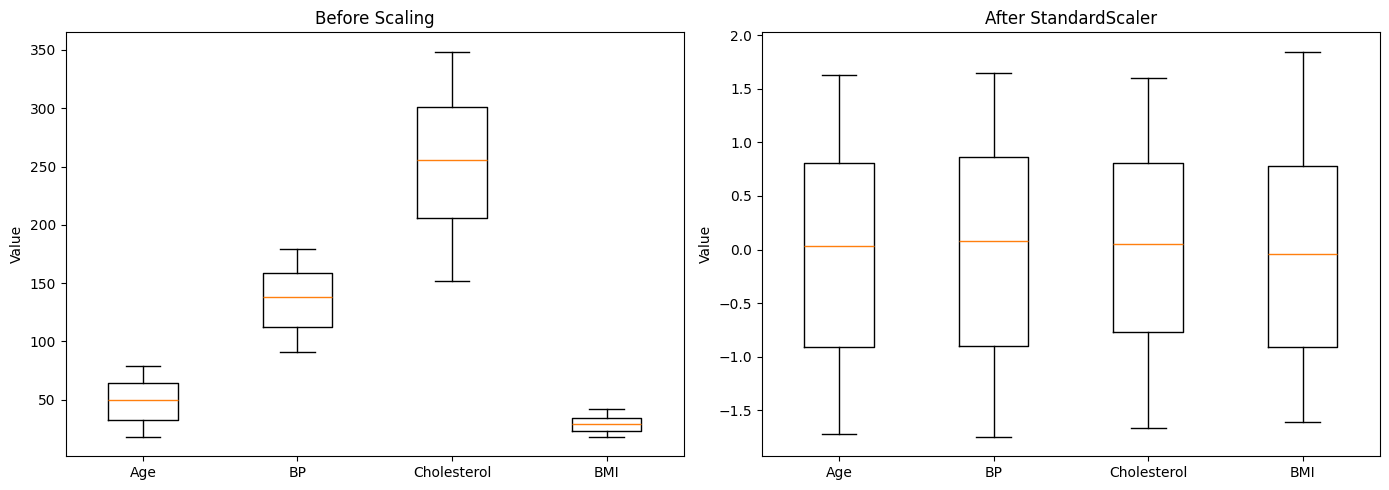

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([x[:, 0], x[:, 1], x[:, 2], x[:, 3]],
                tick_labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[0].set_title('Before Scaling')
axes[0].set_ylabel('Value')

axes[1].boxplot([x_scaled[:, 0], x_scaled[:, 1], x_scaled[:, 2], x_scaled[:, 3]],
                tick_labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[1].set_title("After StandardScaler")
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

### 4.3 - Apply MinMaxScaler (Task)

In [18]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
x_minMax = minmax.fit_transform(x)

minMax_comparison = pd.DataFrame({
    'Feature': feature_cols,
    'Original Mean': x.mean(axis=0).round(2),
    'Original Std': x.std(axis=0).round(2),
    'Scaled Mean': x_minMax.mean(axis=0).round(2),
    'Scaled Std': x_minMax.std(axis=0).round(2)
})

print(minMax_comparison.to_string(index=False))

       Feature  Original Mean  Original Std  Scaled Mean  Scaled Std
           age          49.34         18.19         0.51        0.30
blood_pressure         136.08         26.08         0.51        0.29
   cholesterol         252.36         60.05         0.51        0.31
           bmi          29.33          6.87         0.47        0.29
gender_encoded           0.52          0.50         0.52        0.50
smoker_encoded           0.32          0.47         0.32        0.47
   city_Dammam           0.30          0.46         0.30        0.46
   city_Jeddah           0.26          0.44         0.26        0.44
   city_Makkah           0.21          0.41         0.21        0.41
   city_Riyadh           0.24          0.42         0.24        0.42


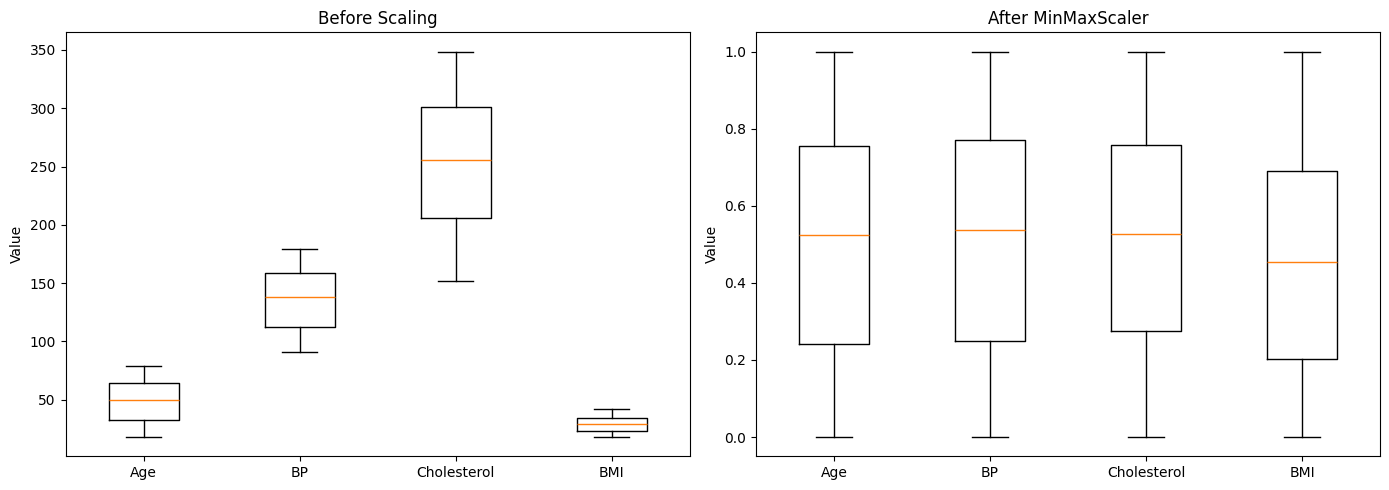

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([x[:, 0], x[:, 1], x[:, 2], x[:, 3]],
                tick_labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[0].set_title('Before Scaling')
axes[0].set_ylabel('Value')

axes[1].boxplot([x_minMax[:, 0], x_minMax[:, 1], x_minMax[:, 2], x_minMax[:, 3]],
                tick_labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[1].set_title("After MinMaxScaler")
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

## If your data has many outliers, which scaler would be more robust? Why?

StandardScaler would be slightly more stable because MinMaxScaler relies on the maximum and minimum values which can skew the data if they were too big or too small compared to the dataset

# Part 5: The Scaling Impact – KNN Before and After

### 5.1 - Experiment: KNN Without Scaling vs. With Scaling


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

x_train_s, x_test_s, _, _ = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)

knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(x_train, y_train)
raw_acc = accuracy_score(y_test, knn_raw.predict(x_test))

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(x_train_s, y_train)
scaled_acc = accuracy_score(y_test, knn_scaled.predict(x_test_s))

print(f"KNN Accuracy without scaling: {raw_acc: .2%}")
print(f"KNN Accuracy with scaling: {scaled_acc: .2%}")
print(f"Improvement: {(scaled_acc - raw_acc): .2%}") # KNN got worse after scaling. I have tried several other methods for train_test_split # to make sure that the data hasn't been split twice, but the result is the same

KNN Accuracy without scaling:  67.50%
KNN Accuracy with scaling:  50.00%
Improvement: -17.50%


### 5.2 - Decision Tree Comparison

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_raw = DecisionTreeClassifier(random_state=42)
dt_raw.fit(x_train, y_train)
dt_raw_acc = accuracy_score(y_test, dt_raw.predict(x_test))

dt_scaled = DecisionTreeClassifier(random_state=42)
dt_scaled.fit(x_train_s, y_train)
dt_scaled_acc = accuracy_score(y_test, dt_scaled.predict(x_test_s))

print(f"DT Accuracy without scaling: {dt_raw_acc: .2%}")
print(f"DT Accuracy with scaling: {dt_scaled_acc: .2%}")

DT Accuracy without scaling:  55.00%
DT Accuracy with scaling:  52.50%


In [22]:
results = pd.DataFrame({
    'Model': ['KNN', 'KNN', 'Decision Tree', 'Decision Tree'],
    'Scaling': ['No', 'Yes', 'No', 'Yes'],
    'Accuracy': [raw_acc, scaled_acc, dt_raw_acc, dt_scaled_acc]
})
print(results)

           Model Scaling  Accuracy
0            KNN      No     0.675
1            KNN     Yes     0.500
2  Decision Tree      No     0.550
3  Decision Tree     Yes     0.525


*  Try KNN with n neighbors=3 and n neighbors=10, both with and without scaling. Does scaling always help?

Results for n_neighbors=3:
KNN Accuracy without scaling:  55.00%
KNN Accuracy with scaling:  47.50%
Improvement: -7.50%

Results for n_neighbors=10:
KNN Accuracy without scaling:  55.00%
KNN Accuracy with scaling:  50.00%
Improvement: -5.00%

In our case, scaling didn't help at all, in fact it reduced the accuracy of KNN

*   Write 2–3 sentences explaining why KNN benefits from scaling but Decision Trees
do not.

KNN relies on Euclidean distance calculations. If features have different scales, those with larger ranges dominate the distance, which can mislead the model. Scaling puts all features on a similar scale, so each contributes fairly.



# Part 6: Building a Preprocessing Pipeline

### 6.1 - Creating a Pipeline

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)

pipe.fit(x_train, y_train)
pipe_acc = accuracy_score(y_test, pipe.predict(x_test))

print(f"Pipeline KNN Accuracy: {pipe_acc: .2%}")

Pipeline KNN Accuracy:  50.00%


### 6.2 - Swap Models Easily

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42))
])

pipe_svm.fit(x_train, y_train)
svm_acc = accuracy_score(y_test, pipe_svm.predict(x_test))

pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

pipe_dt.fit(x_train, y_train)
dt_acc = accuracy_score(y_test, pipe_dt.predict(x_test))

print(f"Pipeline KNN Accuracy: {pipe_acc: .2%}")
print(f"Pipeline SVM Accuracy: {svm_acc: .2%}")
print(f"Pipeline DT Accuracy: {dt_acc: .2%}")

Pipeline KNN Accuracy:  50.00%
Pipeline SVM Accuracy:  55.00%
Pipeline DT Accuracy:  52.50%


In [25]:
knn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

knn_pipe.fit(x_train, y_train)
knn_pipe_acc = accuracy_score(y_test, knn_pipe.predict(x_test))

print(f"Pipeline KNN Accuracy (using MinMaxScaler): {knn_pipe_acc: .2%}")

Pipeline KNN Accuracy (using MinMaxScaler):  50.00%


# Part 7: Feature Selection with Correlation Analysis

### 7.1 - Correlation Matrix

In [26]:
df_processed = pd.DataFrame(x_scaled, columns=feature_cols)
df_processed['heart_disease'] = y

corr_matrix = df_processed.corr()

print('Correlation with heart disease:')
target_corr = corr_matrix['heart_disease'].drop('heart_disease')
print(target_corr.sort_values(ascending=False).round(3))

Correlation with heart disease:
age               0.143
blood_pressure    0.106
city_Riyadh       0.079
city_Dammam       0.067
gender_encoded    0.014
cholesterol       0.003
bmi              -0.004
smoker_encoded   -0.025
city_Makkah      -0.061
city_Jeddah      -0.089
Name: heart_disease, dtype: float64


### 7.2 - Visualize with a Heatmap


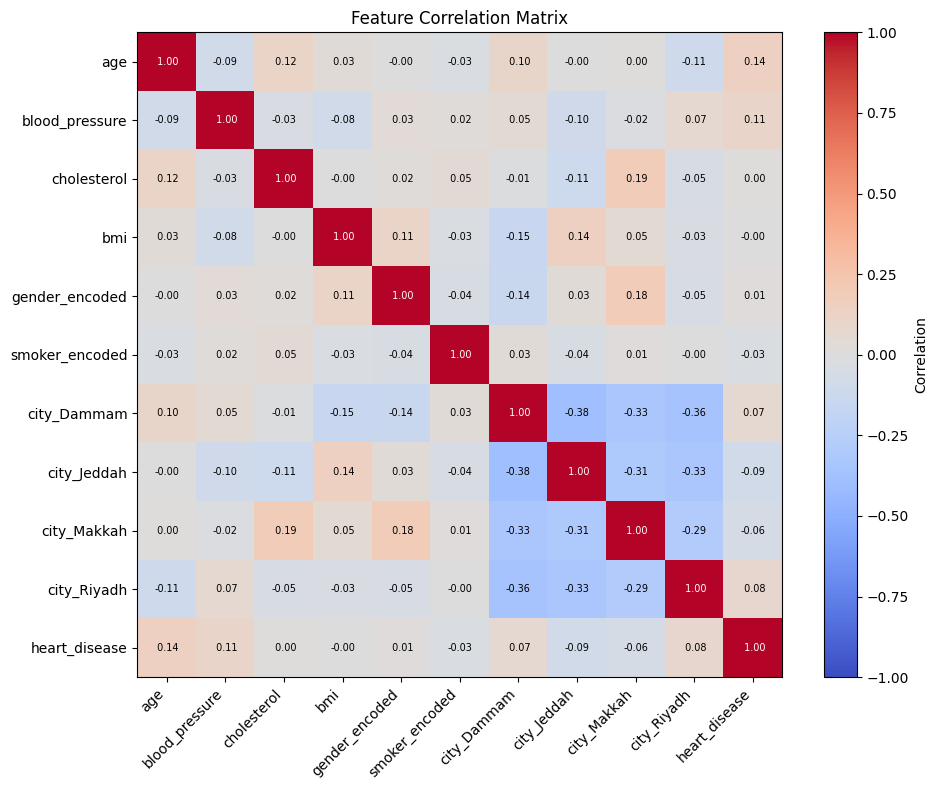

In [27]:
plt.figure(figsize=(10,8))
im = plt.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, label='Correlation')

ticks = range(len(corr_matrix.columns))
plt.xticks(ticks, corr_matrix.columns, rotation=45, ha='right')
plt.yticks(ticks, corr_matrix.columns)
for i in range(len(corr_matrix)):
  for j in range(len(corr_matrix)):
    val = corr_matrix.values[i, j]
    color = 'white' if abs(val) > 0.5 else 'black'
    plt.text(j, i, f'{val: .2f}', ha='center', va='center', fontsize=7, color=color)

plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### 7.3 - Top Features

In [28]:
threshold = 0.10
important_features = target_corr[abs(target_corr) > threshold]
print(f"\nFeatures with |correlation| > {threshold}: ")
print(important_features.sort_values(ascending=False).round(3))
top_features = important_features.index.tolist()
x_selected = df_processed[top_features].values

x_tr, x_te, y_tr, y_te = train_test_split(
    x_selected, y, test_size=0.2, random_state=42, stratify=y)

pipe_selected = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
pipe_selected.fit(x_tr, y_tr)
sel_acc = accuracy_score(y_te, pipe_selected.predict(x_te))

print(f"\nAccuracy with all features: {pipe_acc: .2%}")
print(f"Accuracy with selected features: {sel_acc: .2%}")
print(f"Features used: {len(top_features)} out of {len(feature_cols)}")


Features with |correlation| > 0.1: 
age               0.143
blood_pressure    0.106
Name: heart_disease, dtype: float64

Accuracy with all features:  50.00%
Accuracy with selected features:  60.00%
Features used: 2 out of 10


1- Age has the strongest correlation to heart_disease

2- threshold = 0.10 gave the best accuracy due to the features being considered are highly correlated to the output.


# Part 8: Putting It All Together – Full Workflow

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , classification_report

# ===== STEP 1: Load Raw Data =====
np . random . seed (42)
n = 200
data = {
"age": np.random.randint (18, 80, n) . astype (float),
"blood_pressure": np.round (np.random.uniform(90, 180, n), 1),
"cholesterol": np.round (np.random.uniform (150, 350, n ), 1),
"bmi": np.round (np.random.uniform (18, 42, n ), 1),
"gender": np.random.choice ([ "Male", "Female"], n ),
"city": np.random.choice (
["Jeddah", "Riyadh", "Dammam", "Makkah"], n ) ,
"smoker": np.random.choice(["Yes", "No"], n, p =[0.3 , 0.7]) ,
"heart_disease": np.random.choice([0 , 1], n, p =[0.6 , 0.4])
}
df = pd.DataFrame(data)
missing_idx = np.random.choice (n, 20, replace = False)
df.loc[missing_idx[:10], "age"] = np.nan
df.loc[missing_idx[10:15], "blood_pressure"] = np.nan
df.loc[missing_idx[15:], "cholesterol"] = np.nan

print("=== Step 1: Raw Data ===")
print(f"Shape: {df.shape}, Missing: {df.isnull().sum().sum()}")

# ===== STEP 2: Handle Missing Values =====
num_cols = ['age', 'blood_pressure', 'cholesterol']
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])
print("\n=== Step 2: After Imputation ===")
print(f"Missing: {df.isnull().sum().sum()}")

# ===== STEP 3: Encode Categorical Variables =====
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['smoker'] = le.fit_transform(df['smoker'])
df = pd.concat([
    df, pd.get_dummies(df['city'], prefix='city')], axis=1)
df = df.drop(columns=['city'])
print(f"\n=== Step 3: After Encoding ===")
print(f"Columns: {df.columns}")

# ===== STEP 4: Separate Features and Target =====
X = df.drop(columns=['heart_disease']).values
y = df['heart_disease'].values

# ===== STEP 5: Split Data =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ===== STEP 6: Build Pipeline & Train =====
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(random_state=42))
])

pipe_knn.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)

# ===== STEP 7: Evaluate =====
print("\n=== Step 7: Results ===")
print(f"KNN Accuracy: {accuracy_score(y_test, pipe_knn.predict(X_test)): .2%}")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, pipe_dt.predict(X_test)): .2%}")

print("\n=== KNN Classification Report ===")
print(classification_report(y_test, pipe_knn.predict(X_test), target_names=['No Disease', 'Disease']))

=== Step 1: Raw Data ===
Shape: (200, 8), Missing: 20

=== Step 2: After Imputation ===
Missing: 0

=== Step 3: After Encoding ===
Columns: Index(['age', 'blood_pressure', 'cholesterol', 'bmi', 'gender', 'smoker',
       'heart_disease', 'city_Dammam', 'city_Jeddah', 'city_Makkah',
       'city_Riyadh'],
      dtype='object')

=== Step 7: Results ===
KNN Accuracy:  50.00%
Decision Tree Accuracy:  52.50%

=== KNN Classification Report ===
              precision    recall  f1-score   support

  No Disease       0.54      0.68      0.60        22
     Disease       0.42      0.28      0.33        18

    accuracy                           0.50        40
   macro avg       0.48      0.48      0.47        40
weighted avg       0.48      0.50      0.48        40



The preprocessing step which influenced the most model performance was feature scaling with the StandardScaler, particularly with the KNN model. KNN uses the distances between data points to compute its elements and therefore when features are extremely different (e.g. age vs. cholesterol) then the larger values will dominate the distance calculation. Scaling normalizes the features in a manner that they equally contribute to the model. The process of encoding categorical variables was also required due to the fact that machine learning models have numerical requirements. Preprocessing has been important in real-world machine learning projects since raw data is usually sloppy, incomplete, and inconsistent. Effective preprocessing enhances the model accuracy, stability and reliability. These steps are necessary to ensure that even strong models can give poor or misleading predictions.